# Analiza czynników wpływających na popularność utworów Spotify

## 1. Import bibliotek

In [36]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 2. Wczytanie danych

In [37]:
from pathlib import Path
from google.colab import drive


drive.mount('/content/drive')


csv_path = Path("/content/drive/MyDrive/projekt_PROW/dataset/dataset.csv")


df = pd.read_csv(csv_path)

print("Wczytany plik:", csv_path)
print("Rozmiar danych:", df.shape)
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wczytany plik: /content/drive/MyDrive/projekt_PROW/dataset/dataset.csv
Rozmiar danych: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Struktura danych

In [38]:
print("Kolumny:")
display(df.columns.tolist())

print("\nTypy danych:")
display(df.dtypes.to_frame("typ_danych"))

print("\nBraki danych:")
missing = df.isna().sum().to_frame("liczba_braków")
missing["procent_braków"] = (missing["liczba_braków"] / len(df) * 100).round(4)
display(missing)

print("\nDuplikaty całych wierszy:", df.duplicated().sum())

Kolumny:


['Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']


Typy danych:


,typ_danych
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64



Braki danych:


,liczba_braków,procent_braków
Unnamed: 0,0,0.0000
track_id,0,0.0000
artists,1,0.0009
album_name,1,0.0009
track_name,1,0.0009
popularity,0,0.0000
duration_ms,0,0.0000
explicit,0,0.0000
danceability,0,0.0000
energy,0,0.0000



Duplikaty całych wierszy: 0


## 4. Czyszczenie danych

In [39]:
df_clean = df.copy()

cols_to_drop = [col for col in df_clean.columns if col.lower().startswith("unnamed")]
df_clean = df_clean.drop(columns=cols_to_drop)

required_text_cols = [col for col in ["artists", "album_name", "track_name"] if col in df_clean.columns]
df_clean = df_clean.dropna(subset=required_text_cols)

rows_before_dedup = len(df_clean)

df_unique_all = df_clean.drop_duplicates(subset=["track_id"]).copy()

df_unique_all["duration_min"] = df_unique_all["duration_ms"] / 60000

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"
]

main_cols = ["popularity"] + audio_features


df_audio_all = df_unique_all[main_cols].dropna().copy()

zero_popularity_count = (df_audio_all["popularity"] == 0).sum()
zero_popularity_percent = zero_popularity_count / len(df_audio_all) * 100


df_unique = df_unique_all[df_unique_all["popularity"] > 0].copy()
df_audio = df_audio_all[df_audio_all["popularity"] > 0].copy()

print("Liczba rekordów w surowych danych:", len(df))
print("Liczba rekordów po usunięciu braków opisowych:", rows_before_dedup)
print("Liczba rekordów po zostawieniu jednego rekordu na utwór:", len(df_unique_all))
print("Liczba utworów z popularity = 0:", zero_popularity_count)
print("Odsetek utworów z popularity = 0:", round(zero_popularity_percent, 2), "%")
print("Liczba rekordów w głównej analizie po usunięciu popularity = 0:", len(df_audio))

Liczba rekordów w surowych danych: 114000
Liczba rekordów po usunięciu braków opisowych: 113999
Liczba rekordów po zostawieniu jednego rekordu na utwór: 89740
Liczba utworów z popularity = 0: 9447
Odsetek utworów z popularity = 0: 10.53 %
Liczba rekordów w głównej analizie po usunięciu popularity = 0: 80293


## 5. Statystyki opisowe

In [52]:
summary = df_audio.describe().T
summary["missing"] = df_audio.isna().sum()

display(Markdown("### Statystyki opisowe po usunięciu `popularity = 0`"))
display(summary.round(3))

display(Markdown("### Porównanie liczby rekordów przed i po usunięciu `popularity = 0`"))
cleaning_summary = pd.DataFrame({
    "etap": [
        "po usunięciu duplikatów track_id",
        "usunięte rekordy z popularity = 0",
        "główna analiza bez popularity = 0"
    ],
    "liczba_rekordów": [
        len(df_audio_all),
        zero_popularity_count,
        len(df_audio)
    ],
    "procent_względem_df_audio_all": [
        100,
        zero_popularity_percent,
        len(df_audio) / len(df_audio_all) * 100
    ]
})

display(cleaning_summary.round(3))

### Statystyki opisowe po usunięciu `popularity = 0`

,count,mean,std,min,25%,50%,75%,max,missing
popularity,80293.0,37.105,18.124,1.000,22.000,37.000,50.000,100.000,0
danceability,80293.0,0.563,0.176,0.000,0.452,0.576,0.692,0.985,0
energy,80293.0,0.641,0.254,0.000,0.466,0.682,0.858,1.000,0
loudness,80293.0,-8.451,5.153,-49.531,-10.275,-7.195,-5.108,4.532,0
speechiness,80293.0,0.089,0.117,0.000,0.036,0.049,0.087,0.965,0
acousticness,80293.0,0.321,0.335,0.000,0.015,0.181,0.611,0.996,0
instrumentalness,80293.0,0.179,0.327,0.000,0.000,0.000,0.124,1.000,0
liveness,80293.0,0.220,0.199,0.000,0.098,0.133,0.284,1.000,0
valence,80293.0,0.468,0.262,0.000,0.249,0.455,0.679,0.995,0
tempo,80293.0,122.478,30.079,0.000,99.949,122.394,140.890,243.372,0


### Porównanie liczby rekordów przed i po usunięciu `popularity = 0`

,etap,liczba_rekordów,procent_względem_df_audio_all
0,po usunięciu duplikatów track_id,89740,100.000
1,usunięte rekordy z popularity = 0,9447,10.527
2,główna analiza bez popularity = 0,80293,89.473


## 6. Rozkład popularności

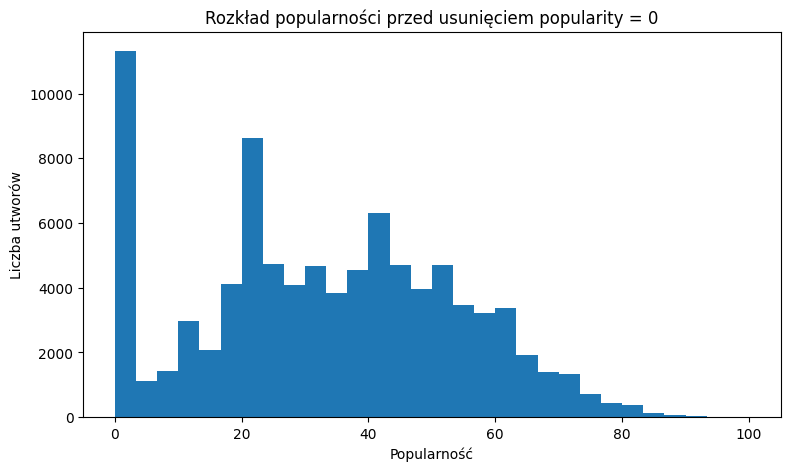

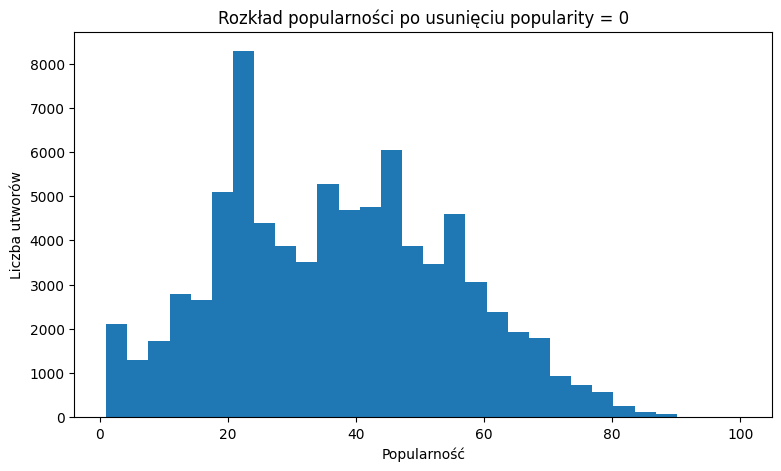

,metryka,przed_usunięciem_0,po_usunięciu_0
0,liczba rekordów,89740.000,80293.000
1,średnia,33.199,37.105
2,mediana,33.000,37.000
3,minimum,0.000,1.000
4,maksimum,100.000,100.000
5,liczba utworów z popularity = 0,9447.000,0.000
6,odsetek utworów z popularity = 0,10.527,0.000
7,liczba utworów popularnych: popularity >= 70,3126.000,3126.000
8,odsetek utworów popularnych: popularity >= 70,3.483,3.893


In [41]:
plt.figure(figsize=(9, 5))
plt.hist(df_audio_all["popularity"], bins=30)
plt.title("Rozkład popularności przed usunięciem popularity = 0")
plt.xlabel("Popularność")
plt.ylabel("Liczba utworów")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(df_audio["popularity"], bins=30)
plt.title("Rozkład popularności po usunięciu popularity = 0")
plt.xlabel("Popularność")
plt.ylabel("Liczba utworów")
plt.show()

popularity_stats = pd.DataFrame({
    "metryka": [
        "liczba rekordów",
        "średnia",
        "mediana",
        "minimum",
        "maksimum",
        "liczba utworów z popularity = 0",
        "odsetek utworów z popularity = 0",
        "liczba utworów popularnych: popularity >= 70",
        "odsetek utworów popularnych: popularity >= 70"
    ],
    "przed_usunięciem_0": [
        len(df_audio_all),
        df_audio_all["popularity"].mean(),
        df_audio_all["popularity"].median(),
        df_audio_all["popularity"].min(),
        df_audio_all["popularity"].max(),
        (df_audio_all["popularity"] == 0).sum(),
        (df_audio_all["popularity"] == 0).mean() * 100,
        (df_audio_all["popularity"] >= 70).sum(),
        (df_audio_all["popularity"] >= 70).mean() * 100
    ],
    "po_usunięciu_0": [
        len(df_audio),
        df_audio["popularity"].mean(),
        df_audio["popularity"].median(),
        df_audio["popularity"].min(),
        df_audio["popularity"].max(),
        (df_audio["popularity"] == 0).sum(),
        (df_audio["popularity"] == 0).mean() * 100,
        (df_audio["popularity"] >= 70).sum(),
        (df_audio["popularity"] >= 70).mean() * 100
    ]
})

display(popularity_stats.round(3))

## 7. Rozkłady cech audio

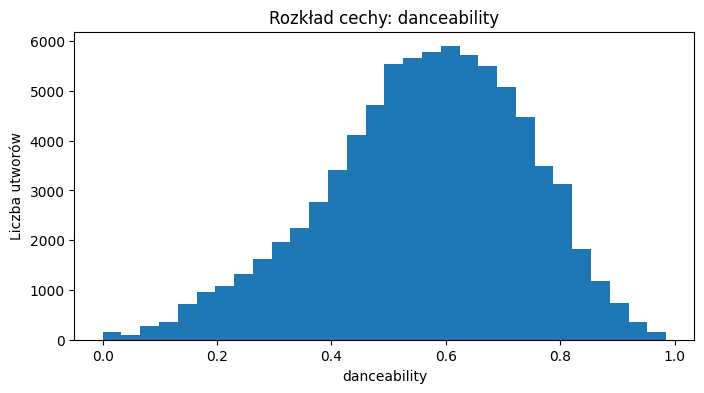

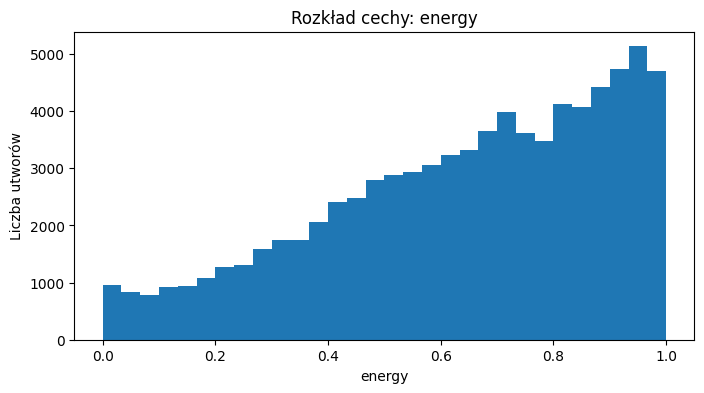

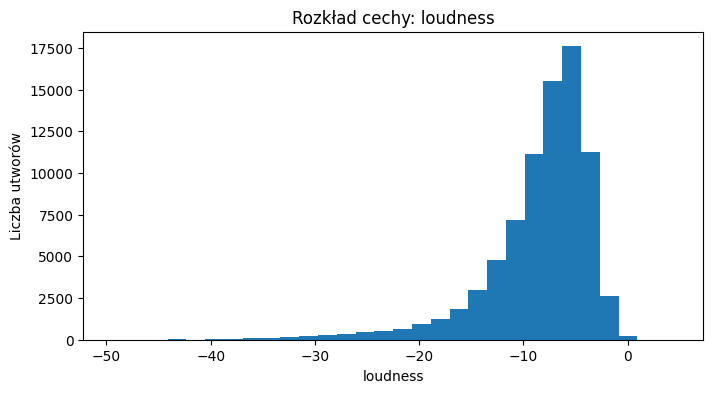

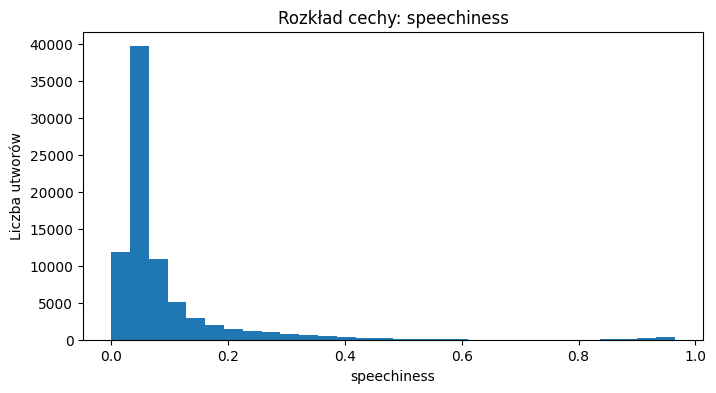

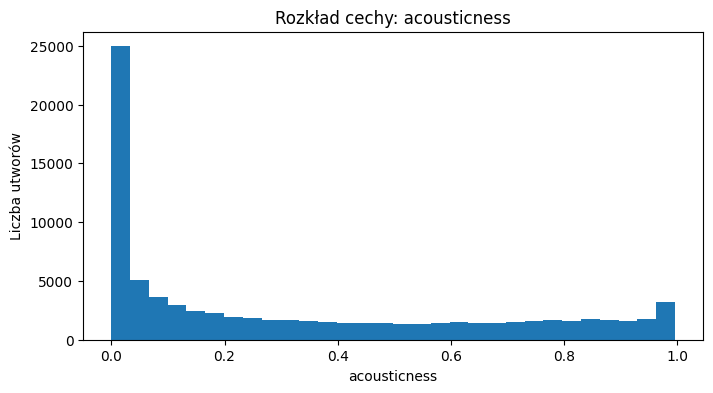

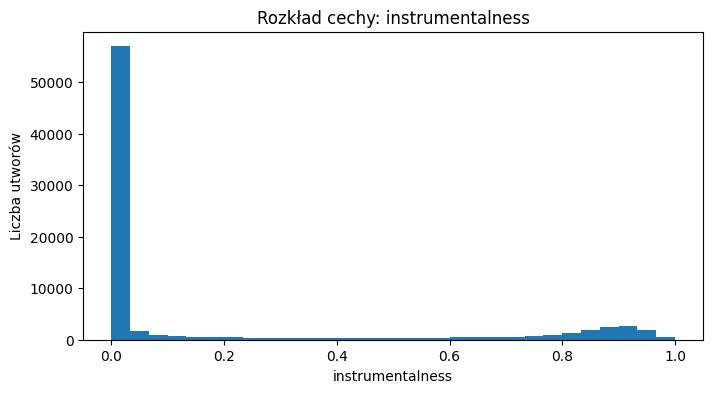

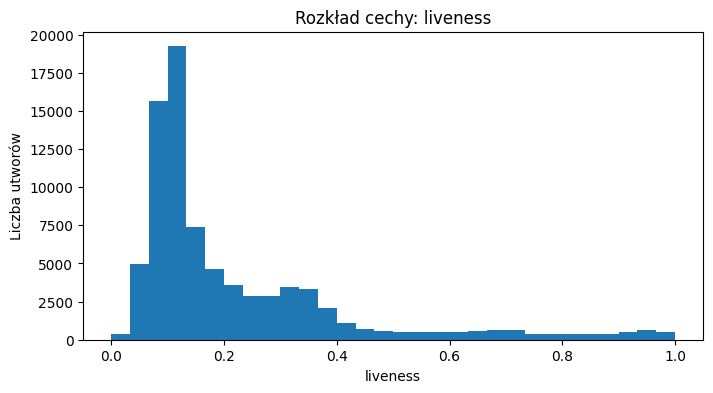

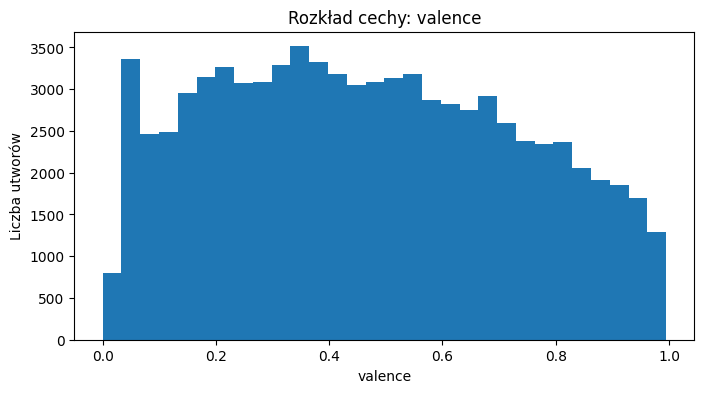

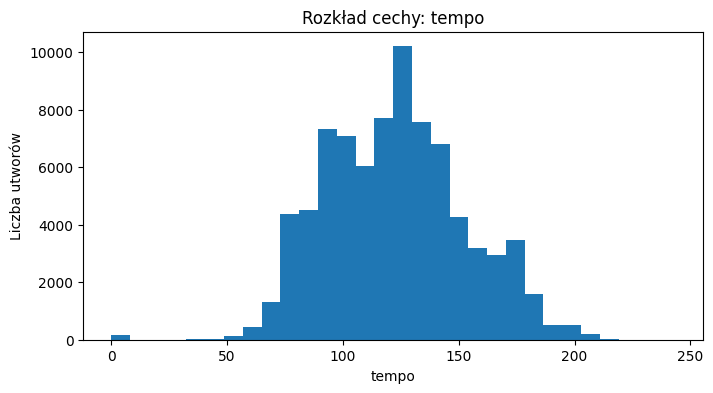

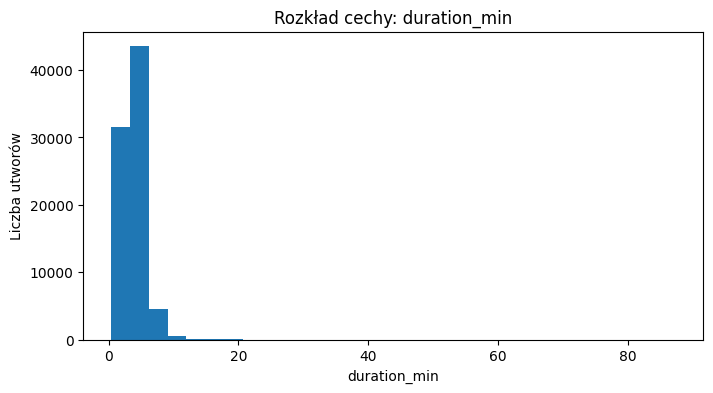

In [42]:
for feature in audio_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df_audio[feature], bins=30)
    plt.title(f"Rozkład cechy: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Liczba utworów")
    plt.show()

## 8. Korelacje z popularnością

### Korelacje cech audio z popularnością - porównanie przed i po usunięciu `popularity = 0`

,korelacja_przed_usunięciem_0,korelacja_po_usunięciu_0
instrumentalness,-0.1275,-0.1949
speechiness,-0.0471,-0.0851
danceability,0.0643,0.0742
loudness,0.0717,0.0731
duration_min,-0.0232,-0.0602
liveness,-0.0139,-0.0503
energy,0.0137,-0.0342
tempo,0.0073,-0.0193
acousticness,-0.0388,-0.0068
valence,-0.0115,-0.0019


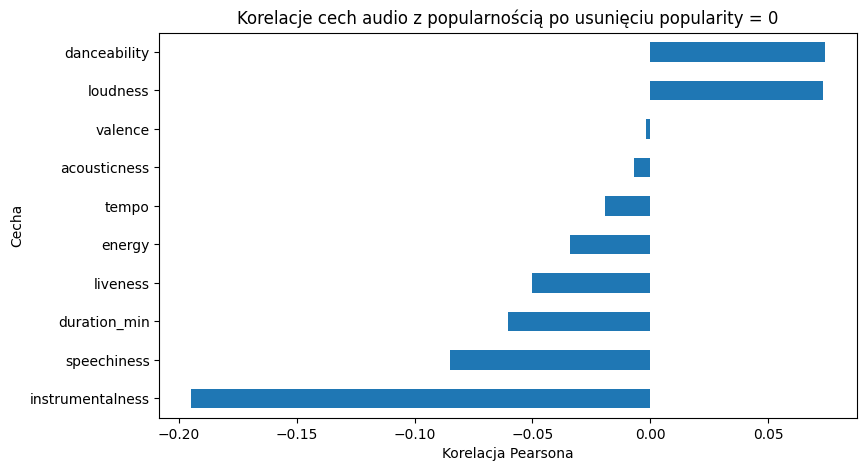

In [43]:
corr_matrix = df_audio.corr(numeric_only=True)




corr_series_without_popularity = corr_matrix["popularity"].drop("popularity")
corr_with_popularity = corr_series_without_popularity.reindex(corr_series_without_popularity.abs().sort_values(ascending=False).index)

corr_matrix_all = df_audio_all.corr(numeric_only=True)
corr_with_popularity_all = corr_matrix_all["popularity"].drop("popularity")

corr_comparison = pd.DataFrame({
    "korelacja_przed_usunięciem_0": corr_with_popularity_all,
    "korelacja_po_usunięciu_0": corr_with_popularity
}).loc[corr_with_popularity.index]

display(Markdown("### Korelacje cech audio z popularnością - porównanie przed i po usunięciu `popularity = 0`"))
display(corr_comparison.round(4))

plt.figure(figsize=(9, 5))
corr_with_popularity.sort_values().plot(kind="barh")
plt.title("Korelacje cech audio z popularnością po usunięciu popularity = 0")
plt.xlabel("Korelacja Pearsona")
plt.ylabel("Cecha")
plt.show()

## 9. Mapa korelacji

Mapa korelacji pozwala zobaczyć nie tylko związek cech z popularnością, ale też zależności między samymi cechami audio.

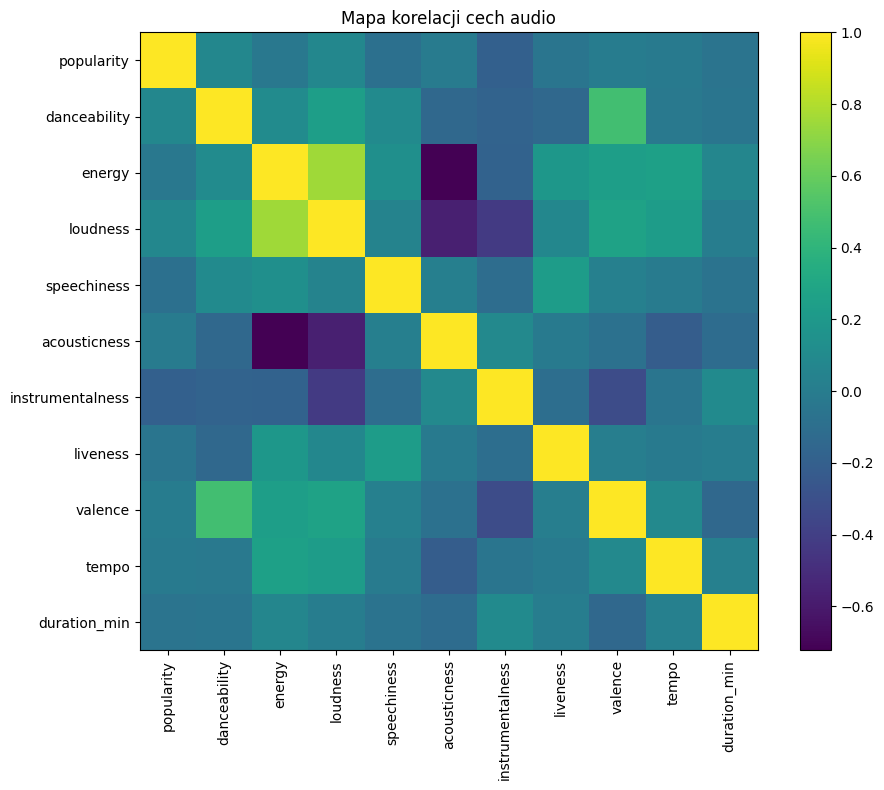

In [44]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Mapa korelacji cech audio")
plt.tight_layout()
plt.show()

## 10. Popularność a wybrane cechy audio

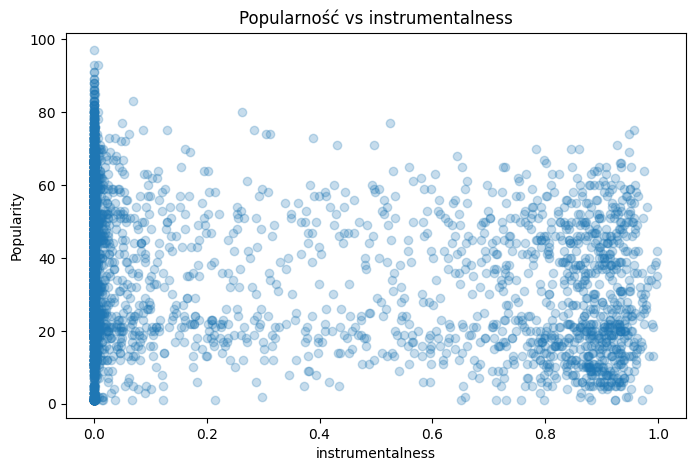

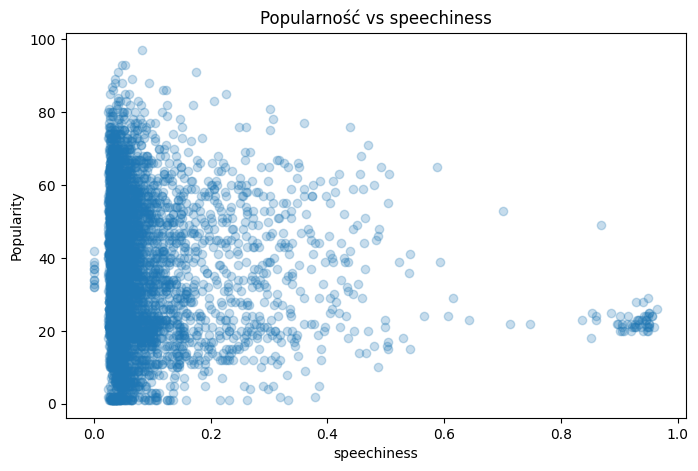

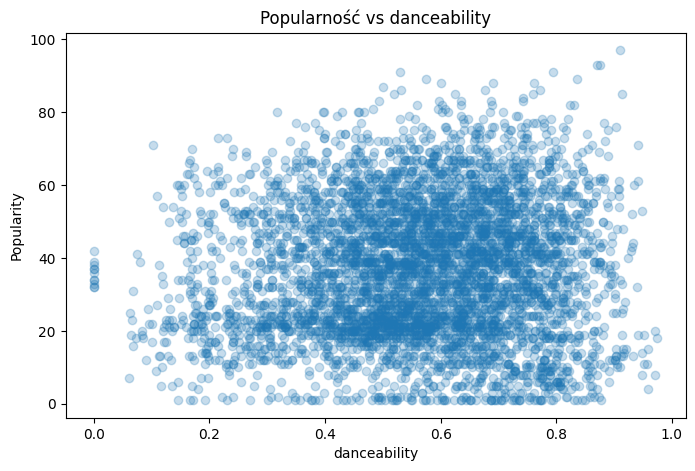

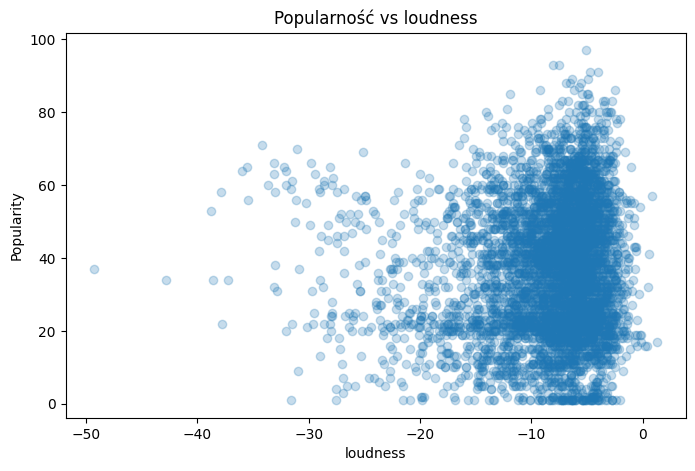

In [45]:
sample_df = df_audio.sample(n=min(5000, len(df_audio)), random_state=42)

top_corr_features = corr_with_popularity.abs().sort_values(ascending=False).head(4).index.tolist()

for feature in top_corr_features:
    plt.figure(figsize=(8, 5))
    plt.scatter(sample_df[feature], sample_df["popularity"], alpha=0.25)
    plt.title(f"Popularność vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("Popularity")
    plt.show()

## 11. Porównanie: utwory popularne vs mniej popularne

In [46]:
df_groups = df_audio.copy()
df_groups["popularity_group"] = np.where(
    df_groups["popularity"] >= 70,
    "popularne (>=70)",
    "mniej popularne (<70)"
)

group_counts = df_groups.groupby("popularity_group")["popularity"].agg(["count", "mean", "median", "min", "max"])
display(group_counts.round(3))

group_means = df_groups.groupby("popularity_group")[audio_features].mean().T
group_medians = df_groups.groupby("popularity_group")[audio_features].median().T

display(Markdown("### Średnie wartości cech audio"))
display(group_means.round(4))

display(Markdown("### Mediany cech audio"))
display(group_medians.round(4))

,count,mean,median,min,max
popularity_group,,,,,
mniej popularne (<70),77167,35.548,36.0,1,69
popularne (>=70),3126,75.544,74.0,70,100


### Średnie wartości cech audio

popularity_group,mniej popularne (<70),popularne (>=70)
danceability,0.5604,0.6221
energy,0.6400,0.6640
loudness,-8.5207,-6.7315
speechiness,0.0893,0.0804
acousticness,0.3250,0.2297
instrumentalness,0.1849,0.0340
liveness,0.2221,0.1738
valence,0.4661,0.5115
tempo,122.5503,120.6866
duration_min,3.8575,3.6240


### Mediany cech audio

popularity_group,mniej popularne (<70),popularne (>=70)
danceability,0.5740,0.6330
energy,0.6820,0.6910
loudness,-7.2530,-6.0055
speechiness,0.0492,0.0489
acousticness,0.1860,0.1170
instrumentalness,0.0001,0.0000
liveness,0.1340,0.1230
valence,0.4520,0.5075
tempo,122.7110,119.9830
duration_min,3.5954,3.5048


<Figure size 1000x600 with 0 Axes>

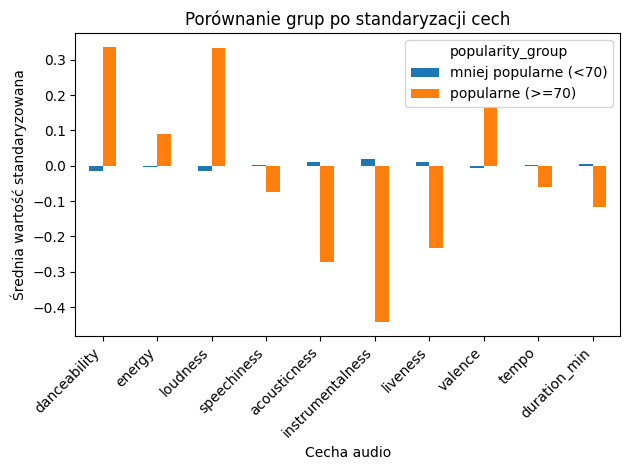

In [47]:
df_standardized = df_groups.copy()
df_standardized[audio_features] = (df_standardized[audio_features] - df_standardized[audio_features].mean()) / df_standardized[audio_features].std()

standardized_group_means = df_standardized.groupby("popularity_group")[audio_features].mean().T

plt.figure(figsize=(10, 6))
standardized_group_means.plot(kind="bar")
plt.title("Porównanie grup po standaryzacji cech")
plt.xlabel("Cecha audio")
plt.ylabel("Średnia wartość standaryzowana")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Wielkość różnic między grupami


- około 0.2 - mały efekt,
- około 0.5 - średni efekt,
- około 0.8 - duży efekt.

,cohen_d_popular_vs_less_popular
instrumentalness,-0.4624
danceability,0.3517
loudness,0.3480
acousticness,-0.2851
liveness,-0.2431
valence,0.1734
duration_min,-0.1218
energy,0.0946
speechiness,-0.0768
tempo,-0.0620


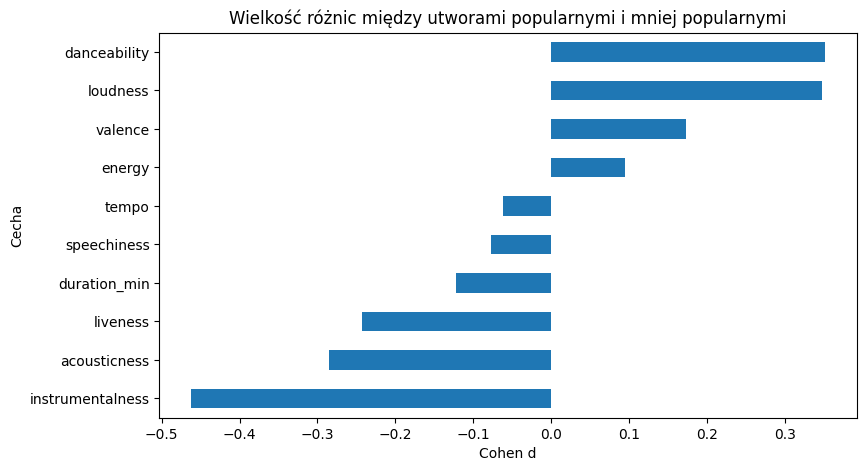

In [48]:
def cohen_d(group_a, group_b):
    a = np.asarray(pd.Series(group_a).dropna())
    b = np.asarray(pd.Series(group_b).dropna())
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return np.nan
    return (a.mean() - b.mean()) / pooled_std

popular = df_groups[df_groups["popularity_group"] == "popularne (>=70)"]
less_popular = df_groups[df_groups["popularity_group"] == "mniej popularne (<70)"]

effect_sizes = pd.Series({
    feature: cohen_d(popular[feature], less_popular[feature])
    for feature in audio_features
}).sort_values(key=lambda s: s.abs(), ascending=False)

display(effect_sizes.to_frame("cohen_d_popular_vs_less_popular").round(4))

plt.figure(figsize=(9, 5))
effect_sizes.sort_values().plot(kind="barh")
plt.title("Wielkość różnic między utworami popularnymi i mniej popularnymi")
plt.xlabel("Cohen d")
plt.ylabel("Cecha")
plt.show()

## 13. Analiza gatunków muzycznych

,liczba_utworow,srednia_popularity,mediana_popularity,odsetek_popularnych_70
track_genre,,,,
k-pop,912,59.684,61.0,23.355
pop-film,813,59.242,60.0,6.396
metal,226,57.920,64.0,21.239
latino,358,57.575,51.5,39.106
soul,207,57.217,63.0,26.087
edm,492,57.043,63.0,23.171
electro,359,56.994,66.0,36.212
pop,309,56.469,67.0,34.951
chill,934,55.925,57.0,4.818


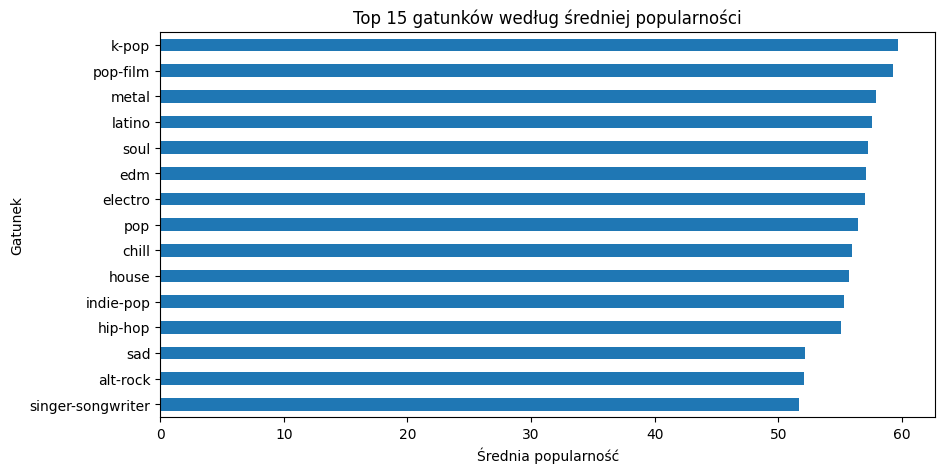

In [49]:
genre_summary = (
    df_unique
    .groupby("track_genre")
    .agg(
        liczba_utworow=("popularity", "size"),
        srednia_popularity=("popularity", "mean"),
        mediana_popularity=("popularity", "median"),
        odsetek_popularnych_70=("popularity", lambda s: (s >= 70).mean() * 100)
    )
    .sort_values("srednia_popularity", ascending=False)
)

display(genre_summary.head(15).round(3))

plt.figure(figsize=(10, 5))
genre_summary.head(15)["srednia_popularity"].sort_values().plot(kind="barh")
plt.title("Top 15 gatunków według średniej popularności")
plt.xlabel("Średnia popularność")
plt.ylabel("Gatunek")
plt.show()

## 14. Ryzyko "one hit wonder"

In [50]:
artist_counts = df_unique["artists"].value_counts()
df_unique["artist_track_count"] = df_unique["artists"].map(artist_counts)

one_track_artists = (artist_counts == 1).sum()
all_artists = artist_counts.size

print("Liczba unikalnych artystów:", all_artists)
print("Liczba artystów z jednym utworem:", one_track_artists)
print("Odsetek artystów z jednym utworem:", round(one_track_artists / all_artists * 100, 2), "%")

df_artist3 = df_unique[df_unique["artist_track_count"] >= 3].copy()
df_artist3_audio = df_artist3[["popularity"] + audio_features].dropna()

print("\nLiczba utworów po zostawieniu artystów z co najmniej 3 utworami:", len(df_artist3_audio))

corr_artist3 = (
    df_artist3_audio
    .corr(numeric_only=True)["popularity"]
    .drop("popularity")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(corr_artist3.to_frame("korelacja_po_filtrze_artystów_3plus").round(4))

Liczba unikalnych artystów: 29814
Liczba artystów z jednym utworem: 19573
Odsetek artystów z jednym utworem: 65.65 %

Liczba utworów po zostawieniu artystów z co najmniej 3 utworami: 52450


,korelacja_po_filtrze_artystów_3plus
instrumentalness,-0.2171
speechiness,-0.1024
loudness,0.0929
danceability,0.0465
duration_min,-0.0354
liveness,-0.0321
energy,-0.0251
acousticness,-0.0095
tempo,-0.0019
valence,0.0005


## 15. Dodatkowa kontrola: czy same cechy audio przewidują popularność?

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = df_audio[audio_features]
y = df_audio["popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = make_pipeline(StandardScaler(), LinearRegression())
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

rf_model = RandomForestRegressor(
    n_estimators=80,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

model_results = pd.DataFrame({
    "model": ["Regresja liniowa", "Random Forest"],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ],
    "MAE": [
        mean_absolute_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ]
})

display(model_results.round(4))

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=audio_features
).sort_values(ascending=False)

display(feature_importance.to_frame("ważność_cechy_random_forest").round(4))

plt.figure(figsize=(9, 5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Ważność cech w modelu Random Forest")
plt.xlabel("Ważność cechy")
plt.ylabel("Cecha")
plt.show()

NameError: name 'mean_absolute_absolute_error' is not defined